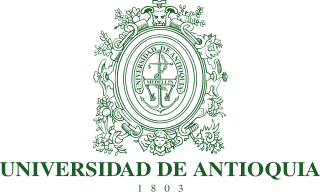

# **Solución alternativa - Introducción a la Inteligencia Artificial**

Estudiante:
- Ana María Uribe Betancur - CC 1000537653


# Carga de datos

In [ ]:
!pip install catboost
!pip install mord

In [ ]:
# Preprocesamiento

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
from sklearn.preprocessing import LabelEncoder
import zipfile
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Modelamiento
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import median_absolute_error, r2_score, mean_squared_error, accuracy_score, cohen_kappa_score, f1_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier
from mord import LogisticAT
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from scipy.stats import randint, uniform
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
import joblib

In [ ]:
df_train = pd.read_csv("test.csv")
df_train

,ID,PERIODO_ACADEMICO,E_PRGM_ACADEMICO,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,F_TIENEINTERNET.1,F_EDUCACIONMADRE,INDICADOR_1,INDICADOR_2,INDICADOR_3,INDICADOR_4
0,550236,20183,TRABAJO SOCIAL,BOLIVAR,Menos de 500 mil,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica completa,Si,No,N,Si,Si,Si,Primaria completa,0.328,0.219,0.317,0.247
1,98545,20203,ADMINISTRACION COMERCIAL Y DE MERCADEO,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,Si,Si,Técnica o tecnológica completa,0.227,0.283,0.296,0.324
2,499179,20212,INGENIERIA MECATRONICA,BOGOTÁ,Entre 1 millón y menos de 2.5 millones,0,Estrato 3,Si,Secundaria (Bachillerato) incompleta,Si,No,N,No,Si,Si,Secundaria (Bachillerato) completa,0.285,0.228,0.294,0.247
3,782980,20195,CONTADURIA PUBLICA,SUCRE,Entre 1 millón y menos de 2.5 millones,Entre 21 y 30 horas,Estrato 1,No,Primaria incompleta,Si,No,N,No,No,No,Primaria incompleta,0.160,0.408,0.217,0.294
4,785185,20212,ADMINISTRACION DE EMPRESAS,ATLANTICO,Entre 2.5 millones y menos de 4 millones,Entre 11 y 20 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,Si,Si,Secundaria (Bachillerato) completa,0.209,0.283,0.306,0.286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296781,496981,20195,ADMINISTRACION DE EMPRESAS,BOGOTÁ,Entre 2.5 millones y menos de 4 millones,Más de 30 horas,Estrato 1,Si,Primaria incompleta,Si,Si,N,Si,Si,Si,Primaria incompleta,0.168,0.410,0.235,0.300
296782,209415,20183,DERECHO,META,Entre 1 millón y menos de 2.5 millones,0,Estrato 4,Si,Educación profesional completa,Si,No,N,No,Si,Si,Educación profesional completa,0.471,0.184,0.264,0.193
296783,239074,20212,DERECHO,BOGOTÁ,Entre 2.5 millones y menos de 4 millones,Más de 30 horas,Estrato 3,Si,Secundaria (Bachillerato) completa,Si,No,N,No,Si,Si,Educación profesional completa,0.292,0.249,0.276,0.256
296784,963852,20195,INGENIERIA AERONAUTICA,ANTIOQUIA,Entre 5.5 millones y menos de 7 millones,Entre 11 y 20 horas,Estrato 3,Si,Educación profesional completa,Si,No,N,No,Si,Si,Educación profesional completa,0.305,0.219,0.310,0.260


Inicialmente, se visualizan las características de las variables (datos no nulos, tipo de datos), para establecer cómo abordar el preprocesamiento.

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296786 entries, 0 to 296785
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ID                           296786 non-null  int64  
 1   PERIODO_ACADEMICO            296786 non-null  int64  
 2   E_PRGM_ACADEMICO             296786 non-null  object 
 3   E_PRGM_DEPARTAMENTO          296786 non-null  object 
 4   E_VALORMATRICULAUNIVERSIDAD  294063 non-null  object 
 5   E_HORASSEMANATRABAJA         283407 non-null  object 
 6   F_ESTRATOVIVIENDA            282991 non-null  object 
 7   F_TIENEINTERNET              285247 non-null  object 
 8   F_EDUCACIONPADRE             286793 non-null  object 
 9   F_TIENELAVADORA              279527 non-null  object 
 10  F_TIENEAUTOMOVIL             277868 non-null  object 
 11  E_PRIVADO_LIBERTAD           296786 non-null  object 
 12  E_PAGOMATRICULAPROPIO        293979 non-null  object 
 13 

# Preprocesamiento

## 1. Limpieza de datos

### Tratar valores duplicados

Se busca si en el dataset existen valores duplicados. Como no existen, se continúa con la limpieza.

In [ ]:
print(f"Datos duplicados por variable: {df_train.duplicated().sum()}")

Datos duplicados por variable: 0


### Tratar valores nulos

Se buscan los valores nulos y el porcentaje que representan respecto al dataset completo. El porcentaje máximo de valores nulos identificado en el conjunto de datos corresponde a la variable F_TIENEAUTOMOVIL, con un 6.30 % de registros faltantes. Este nivel de ausencia de información se considera razonable y manejable dentro de los estándares comunes en análisis de datos. En términos prácticos, una proporción de datos faltantes inferior al 10 % no suele comprometer la representatividad del conjunto ni introduce sesgos significativos en las estimaciones estadísticas, especialmente cuando los valores faltantes no muestran un patrón sistemático (que se observará más adelante).

In [ ]:
# Calcular número y porcentaje de nulos por columna
nulos_abs = df_train.isnull().sum()
nulos_pct = (nulos_abs / len(df_train)) * 100

# Combinar en un solo DataFrame
nulos_df = pd.DataFrame({
    "Valores nulos": nulos_abs,
    "Porcentaje (%)": nulos_pct.round(2)
}).sort_values(by="Porcentaje (%)", ascending=False)

# Mostrar resultados
print("        Porcentaje de valores nulos por variable\n")
print(nulos_df.to_string())

        Porcentaje de valores nulos por variable

                             Valores nulos  Porcentaje (%)
F_TIENEAUTOMOVIL                     18918            6.37
F_TIENELAVADORA                      17259            5.82
F_TIENECOMPUTADOR                    16439            5.54
F_ESTRATOVIVIENDA                    13795            4.65
E_HORASSEMANATRABAJA                 13379            4.51
F_TIENEINTERNET                      11539            3.89
F_TIENEINTERNET.1                    11539            3.89
F_EDUCACIONMADRE                     10223            3.44
F_EDUCACIONPADRE                      9993            3.37
E_PAGOMATRICULAPROPIO                 2807            0.95
E_VALORMATRICULAUNIVERSIDAD           2723            0.92
ID                                       0            0.00
E_PRGM_DEPARTAMENTO                      0            0.00
E_PRGM_ACADEMICO                         0            0.00
PERIODO_ACADEMICO                        0            0.00
E_PRIV

In [ ]:
# Crear una copia del DataFrame original para no modificarlo directamente
df_imputado = df_train.copy().drop(columns=["ID"])

# Diccionario con las reglas derivadas del análisis exploratorio
recomendaciones = {
    # Numéricas simétricas → media
    'INDICADOR_1': 'media',
    'INDICADOR_2': 'media',

    # Numéricas sesgadas → mediana
    'INDICADOR_3': 'mediana',
    'INDICADOR_4': 'mediana',

    # Categóricas → moda (o "No reporta" si aplica)
    'PERIODO_ACADEMICO': 'moda',
    'E_PRGM_ACADEMICO': 'moda',
    'E_PRGM_DEPARTAMENTO': 'moda',
    'E_VALORMATRICULAUNIVERSIDAD': 'moda',
    'E_HORASSEMANATRABAJA': 'moda',
    'F_ESTRATOVIVIENDA': 'moda',
    'F_TIENEINTERNET': 'moda',
    'F_EDUCACIONPADRE': 'moda',
    'F_TIENELAVADORA': 'moda',
    'F_TIENEAUTOMOVIL': 'moda',
    'E_PRIVADO_LIBERTAD': 'moda',
    'E_PAGOMATRICULAPROPIO': 'moda',
    'F_TIENECOMPUTADOR': 'moda',
    'F_TIENEINTERNET.1': 'moda',
    'F_EDUCACIONMADRE': 'moda',
    'RENDIMIENTO_GLOBAL': 'moda'
}

# Aplicar imputación variable por variable
for col, metodo in recomendaciones.items():
    if col in df_imputado.columns:
        if metodo == 'media':
            valor = df_imputado[col].mean()
            df_imputado[col] = df_imputado[col].fillna(valor)
        elif metodo == 'mediana':
            valor = df_imputado[col].median()
            df_imputado[col] = df_imputado[col].fillna(valor)
        elif metodo == 'moda':
            valor = df_imputado[col].mode().iloc[0]
            df_imputado[col] = df_imputado[col].fillna(valor)
        print(f"{col}: imputado con {metodo} ('{valor}')")

# Verificar que no queden nulos
print("\nValores nulos después de la imputación:")
print(df_imputado.isnull().sum().sort_values(ascending=False).head(10))

INDICADOR_1: imputado con media ('0.26823487630818166')
INDICADOR_2: imputado con media ('0.25998862816979235')
INDICADOR_3: imputado con mediana ('0.278')
INDICADOR_4: imputado con mediana ('0.284')
PERIODO_ACADEMICO: imputado con moda ('20195')
E_PRGM_ACADEMICO: imputado con moda ('DERECHO')
E_PRGM_DEPARTAMENTO: imputado con moda ('BOGOTÁ')
E_VALORMATRICULAUNIVERSIDAD: imputado con moda ('Entre 1 millón y menos de 2.5 millones')
E_HORASSEMANATRABAJA: imputado con moda ('Más de 30 horas')
F_ESTRATOVIVIENDA: imputado con moda ('Estrato 2')
F_TIENEINTERNET: imputado con moda ('Si')
F_EDUCACIONPADRE: imputado con moda ('Secundaria (Bachillerato) completa')
F_TIENELAVADORA: imputado con moda ('Si')
F_TIENEAUTOMOVIL: imputado con moda ('No')
E_PRIVADO_LIBERTAD: imputado con moda ('N')
E_PAGOMATRICULAPROPIO: imputado con moda ('No')
F_TIENECOMPUTADOR: imputado con moda ('Si')
F_TIENEINTERNET.1: imputado con moda ('Si')
F_EDUCACIONMADRE: imputado con moda ('Secundaria (Bachillerato) completa

### Tratar outliers

Se busca si en el dataset existen valores atípicos.

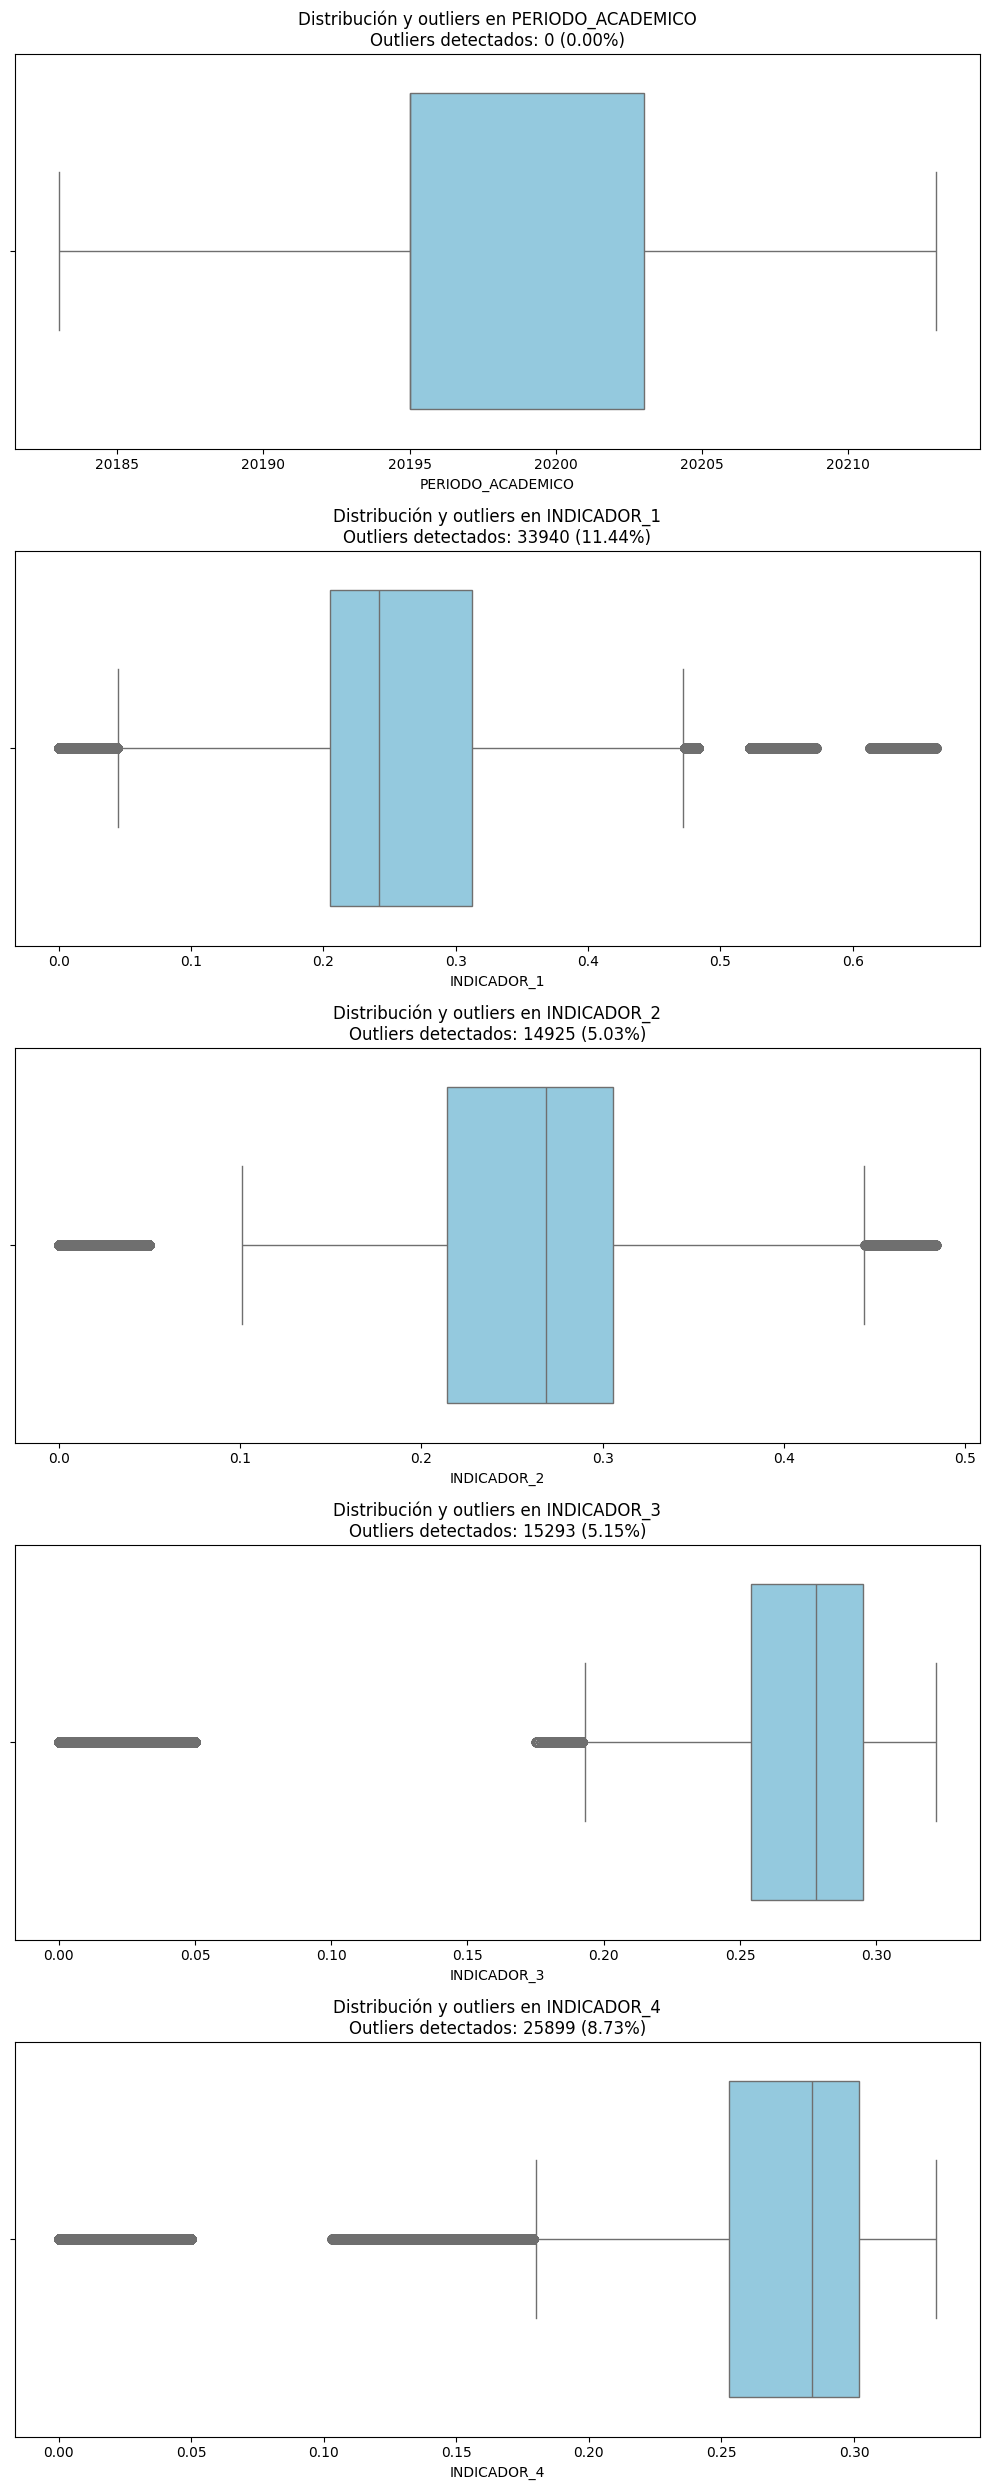

,Variable,Outliers detectados,% del total
1,INDICADOR_1,33940,11.44
4,INDICADOR_4,25899,8.73
3,INDICADOR_3,15293,5.15
2,INDICADOR_2,14925,5.03
0,PERIODO_ACADEMICO,0,0.00


In [ ]:
# Seleccionar solo las variables numéricas
num_cols = df_imputado.select_dtypes(include=["int64", "float64"]).columns

# Crear figura general con subplots
fig, axes = plt.subplots(nrows=len(num_cols), ncols=1, figsize=(10, 5 * len(num_cols)))

if len(num_cols) == 1:
    axes = [axes]  # asegurar iterable

outlier_summary = []  # almacenar resumen

for ax, col in zip(axes, num_cols):
    Q1 = df_imputado[col].quantile(0.25)
    Q3 = df_imputado[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identificar outliers
    mask_outliers = (df_imputado[col] < lower_bound) | (df_imputado[col] > upper_bound)
    num_outliers = mask_outliers.sum()
    perc_outliers = (num_outliers / len(df_imputado)) * 100

    outlier_summary.append({
        "Variable": col,
        "Outliers detectados": num_outliers,
        "% del total": round(perc_outliers, 2)
    })

    # Graficar
    sns.boxplot(x=df_imputado[col], ax=ax, color="skyblue")
    ax.set_title(f"Distribución y outliers en {col}\nOutliers detectados: {num_outliers} ({perc_outliers:.2f}%)")
    ax.set_xlabel(col)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

# Mostrar tabla resumen
outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df.sort_values(by="% del total", ascending=False))

Los outliers en los indicadores de rendimiento probablemente no son errores de medición, sino observaciones extremas pero legítimas. Por ejemplo, un estudiante con una nota muy alta o muy baja podría ser una señal valiosa sobre desempeño real, esfuerzo, o condiciones externas. En modelos predictivos, estos casos pueden ser precisamente los que ayudan al algoritmo a aprender los límites del fenómeno.

Por lo anterior, se decidió no tratar los outliers mediante eliminación. En el proceso de estandarización los pesos específicos de estos indicadores puede reducirse.

## 2. Recodificación


### Recodificación semántica

El objetivo de esta etapa es redefinir cada variable conforme a su naturaleza conceptual, garantizando que los valores representen de manera precisa y coherente la información que contienen. Este proceso implica traducir valores numéricos a etiquetas comprensibles para facilitar su interpretación, reagrupar categorías con baja frecuencia en niveles comunes que reduzcan la dispersión de datos y estandarizar la forma en que las categorías son presentadas. Asimismo, se corrigen inconsistencias derivadas de diferencias en mayúsculas, minúsculas o espacios, como ocurre con respuestas duplicadas del tipo “Sí”, “si” o “SI”. En los casos en que existan variables ordinales, como los niveles educativos o los estratos socioeconómicos, se procede a reetiquetarlas siguiendo un orden lógico. En conjunto, esta fase se apoya en el conocimiento contextual del conjunto de datos y busca asegurar la coherencia semántica y estructural de las variables antes de aplicar cualquier técnica de codificación automática o análisis estadístico.

In [ ]:
# Copiar el dataframe imputado para trabajar con seguridad
df_recode = df_imputado.copy()

# Listas según diagnóstico previo
variables_numericas = [
    "INDICADOR_1", "INDICADOR_2", "INDICADOR_3", "INDICADOR_4"
]

variables_categoricas = [
    "PERIODO_ACADEMICO", "E_PRGM_ACADEMICO", "E_PRGM_DEPARTAMENTO",
    "E_VALORMATRICULAUNIVERSIDAD", "E_HORASSEMANATRABAJA", "F_ESTRATOVIVIENDA",
    "F_TIENEINTERNET", "F_EDUCACIONPADRE", "F_TIENELAVADORA", "F_TIENEAUTOMOVIL",
    "E_PRIVADO_LIBERTAD", "E_PAGOMATRICULAPROPIO", "F_TIENECOMPUTADOR",
    "F_TIENEINTERNET.1", "F_EDUCACIONMADRE" #, "RENDIMIENTO_GLOBAL"
]

# Conversión de tipos de datos
for col in variables_numericas:
    df_recode[col] = pd.to_numeric(df_recode[col], errors='coerce')

for col in variables_categoricas:
    df_recode[col] = df_recode[col].astype('category')

# Validación del resultado
print("\nTIPOS DE DATOS DESPUÉS DE LA RECODIFICACIÓN\n")
print(df_recode.dtypes)

# Confirmar recuento de categorías y valores únicos
print("\nRESUMEN DE DATOS ÚNICOS POR VARIABLE CATEGÓRICA")
display(df_recode[variables_categoricas].nunique())


TIPOS DE DATOS DESPUÉS DE LA RECODIFICACIÓN

PERIODO_ACADEMICO              category
E_PRGM_ACADEMICO               category
E_PRGM_DEPARTAMENTO            category
E_VALORMATRICULAUNIVERSIDAD    category
E_HORASSEMANATRABAJA           category
F_ESTRATOVIVIENDA              category
F_TIENEINTERNET                category
F_EDUCACIONPADRE               category
F_TIENELAVADORA                category
F_TIENEAUTOMOVIL               category
E_PRIVADO_LIBERTAD             category
E_PAGOMATRICULAPROPIO          category
F_TIENECOMPUTADOR              category
F_TIENEINTERNET.1              category
F_EDUCACIONMADRE               category
INDICADOR_1                     float64
INDICADOR_2                     float64
INDICADOR_3                     float64
INDICADOR_4                     float64
dtype: object

RESUMEN DE DATOS ÚNICOS POR VARIABLE CATEGÓRICA


,0
PERIODO_ACADEMICO,9
E_PRGM_ACADEMICO,919
E_PRGM_DEPARTAMENTO,31
E_VALORMATRICULAUNIVERSIDAD,8
E_HORASSEMANATRABAJA,5
F_ESTRATOVIVIENDA,7
F_TIENEINTERNET,2
F_EDUCACIONPADRE,12
F_TIENELAVADORA,2
F_TIENEAUTOMOVIL,2


Convertir columnas de object a category no altera los datos pero sí formaliza su naturaleza discreta y aporta beneficios prácticos, reduce uso de memoria y acelera operaciones al almacenar internamente categorías como códigos enteros, comunica explícitamente que la variable representa clases o niveles (mejorando la claridad semántica para el equipo y el modelado) y facilita la codificación posterior (LabelEncoder u OneHotEncoder) al trabajar sobre un conjunto fijo de categorías, evitando problemas con valores nuevos o inconsistentes.

### Codificación de variables categóricas

Una vez que las variables categóricas han sido limpiadas y estandarizadas, el siguiente paso consiste en transformarlas en una representación numérica que los modelos estadísticos y de machine learning puedan interpretar. Este proceso debe elegirse con base en la naturaleza de cada variable. Para variables nominales (aquellas sin un orden lógico, como el tipo de programa académico o el departamento), la estrategia más apropiada es el One-Hot Encoding, que crea columnas binarias independientes para cada categoría. En cambio, para variables ordinales (como el nivel educativo o el estrato), conviene utilizar Label Encoding o asignar manualmente valores enteros que reflejen su jerarquía. Esta distinción evita distorsionar relaciones entre las variables y garantiza que los algoritmos interpreten correctamente la información. En todo caso, la codificación debe preservarse en un mapeo reproducible para aplicarla de igual forma sobre los datos de prueba o nuevas observaciones.

In [ ]:
# Seleccionar variables categóricas en el dataframe imputado
categorical_cols = df_recode.select_dtypes(include=['category']).columns

# Mostrar los valores únicos (opciones de respuesta) de cada variable categórica
print("VALORES ÚNICOS POR VARIABLE CATEGÓRICA\n")

for col in categorical_cols:
    valores_unicos = df_imputado[col].dropna().unique()
    n_valores = len(valores_unicos)
    print(f"{col} ({n_valores} categorías):")
    print(valores_unicos)
    print("-" * 80)

VALORES ÚNICOS POR VARIABLE CATEGÓRICA

PERIODO_ACADEMICO (9 categorías):
[20183 20203 20212 20195 20196 20194 20213 20202 20184]
--------------------------------------------------------------------------------
E_PRGM_ACADEMICO (919 categorías):
['TRABAJO SOCIAL' 'ADMINISTRACION COMERCIAL Y DE MERCADEO'
 'INGENIERIA MECATRONICA' 'CONTADURIA PUBLICA'
 'ADMINISTRACION DE EMPRESAS' 'ADMINISTRACION AGROPECUARIA'
 'INGENIERIA CIVIL' 'INGENIERÍA MECÁNICA' 'INGENIERÍA DE SISTEMAS'
 'ECONOMIA' 'INGENIERIA INDUSTRIAL' 'PSICOLOGIA'
 'NEGOCIOS INTERNACIONALES' 'ARQUITECTURA' 'INGENIERIA ELECTRICA'
 'SEGURIDAD Y SALUD EN EL TRABAJO' 'INGENIERIA DE SOFTWARE'
 'ADMINISTRACION DE NEGOCIOS' 'MEDICINA VETERINARIA Y ZOOTECNIA' 'DERECHO'
 'INGENIERIA MECANICA' 'ADMINISTRACIÓN DE EMPRESAS' 'PSICOLOGÍA'
 'INGENIERIA AMBIENTAL'
 'LICENCIATURA EN EDUCACION BASICA CON ENFASIS EN INGLES'
 'ECONOMIA Y NEGOCIOS INTERNACIONALES' 'FONOAUDIOLOGIA'
 'PROFESIONAL EN GESTIÓN DE LA SEGURIDAD Y LA SALUD LABORAL'
 'INGEN

Varias conclusiones se derivan de observar las opciones de respuesta de las variables. Entre ellas, que debe compararse las dos variables que preguntan si el estudiante tiene o no acceso a internet (porque serían redundantes), que deben recodificarse las variables ordinales, y que una de las nominales está codificada con opciones de respuesta distintas a las demás, aunque signifiquen lo mismo (E_PRIVADO_LIBERTAD).

Se inicia con la comparación entre las variables redundantes.

In [ ]:
# COMPARACIÓN ENTRE F_TIENEINTERNET Y F_TIENEINTERNET.1
if {'F_TIENEINTERNET', 'F_TIENEINTERNET.1'}.issubset(df_recode.columns):
    # Comparación elemento a elemento
    comparacion = df_recode['F_TIENEINTERNET'] == df_recode['F_TIENEINTERNET.1']

    # Contar coincidencias y discrepancias
    iguales = comparacion.sum()
    diferentes = len(comparacion) - iguales

    print("COMPARACIÓN ENTRE F_TIENEINTERNET Y F_TIENEINTERNET.1")
    print(f"Registros totales: {len(df_recode)}")
    print(f"Coinciden en todos los índices: {iguales == len(df_recode)}")
    print(f"Número de coincidencias: {iguales}")
    print(f"Número de diferencias: {diferentes}")

    # Mostrar las filas donde difieren, si las hay
    if diferentes > 0:
        print("\nFilas con diferencias:")
        display(df_recode.loc[~comparacion, ['F_TIENEINTERNET', 'F_TIENEINTERNET.1']])
else:
    print("Una o ambas columnas no existen en el DataFrame.")

COMPARACIÓN ENTRE F_TIENEINTERNET Y F_TIENEINTERNET.1
Registros totales: 296786
Coinciden en todos los índices: True
Número de coincidencias: 296786
Número de diferencias: 0


In [ ]:
# ELIMINACIÓN DE VARIABLE DUPLICADA
if 'F_TIENEINTERNET.1' in df_recode.columns:
    df_recode = df_recode.drop(columns=['F_TIENEINTERNET.1'])
    print("La columna 'F_TIENEINTERNET.1' ha sido eliminada (era duplicada de 'F_TIENEINTERNET').")
else:
    print("La columna 'F_TIENEINTERNET.1' no existe en el DataFrame o ya fue eliminada.")

La columna 'F_TIENEINTERNET.1' ha sido eliminada (era duplicada de 'F_TIENEINTERNET').


Hecho esto, se procede con la recodificación de todas las variables nominales.

In [ ]:
# Lista de variables a recodificar
vars_binarias = [
    # "PERIODO_ACADEMICO",
    # "E_PRGM_ACADEMICO",
    # "E_PRGM_DEPARTAMENTO",
    "F_TIENEINTERNET",
    "F_TIENELAVADORA",
    "F_TIENEAUTOMOVIL",
    "E_PRIVADO_LIBERTAD",
    "E_PAGOMATRICULAPROPIO",
    "F_TIENECOMPUTADOR"
]

# Función de recodificación (Sí/S = 1, No/N = 0)
def recodificar_binaria(valor):
    if pd.isna(valor):
        return np.nan
    valor = str(valor).strip().upper()
    if valor in ['SI', 'S', '1']:
        return 1
    elif valor in ['NO', 'N', '0']:
        return 0
    else:
        return np.nan

# Aplicar la recodificación
df_nominales = df_recode.copy()
for col in vars_binarias:
    if col in df_nominales.columns:
        df_nominales[col] = df_nominales[col].apply(recodificar_binaria).astype('Int64')

# Confirmar la recodificación
print("\nVARIABLES RECODIFICADAS\n")
for col in vars_binarias:
    if col in df_nominales.columns:
        print(f"{col}: {df_nominales[col].unique()}")


VARIABLES RECODIFICADAS

F_TIENEINTERNET: <IntegerArray>
[1, 0]
Length: 2, dtype: Int64
F_TIENELAVADORA: <IntegerArray>
[1, 0]
Length: 2, dtype: Int64
F_TIENEAUTOMOVIL: <IntegerArray>
[0, 1]
Length: 2, dtype: Int64
E_PRIVADO_LIBERTAD: <IntegerArray>
[0, 1]
Length: 2, dtype: Int64
E_PAGOMATRICULAPROPIO: <IntegerArray>
[1, 0]
Length: 2, dtype: Int64
F_TIENECOMPUTADOR: <IntegerArray>
[1, 0]
Length: 2, dtype: Int64


Se reagrupan las variables poco significativas (con frecuencia menor al 1%) para que las variables no sea tan pesadas a la hora de modelar.

In [ ]:
# Copiar dataframe para no alterar el original
df_umbral = df_nominales.copy()

# Umbral de frecuencia relativa para reagrupar categorías
umbral = 0.01  # 1%

# Reagrupar departamentos
freq_dep = df_umbral['E_PRGM_DEPARTAMENTO'].value_counts(normalize=True)
categorias_raras_dep = freq_dep[freq_dep < umbral].index.tolist()
df_umbral['E_PRGM_DEPARTAMENTO'] = df_umbral['E_PRGM_DEPARTAMENTO'].replace(categorias_raras_dep, 'Otro')
print("Frecuencia de departamentos tras reagrupar 'Otro':")
print(df_umbral['E_PRGM_DEPARTAMENTO'].value_counts())

# Reagrupar programas académicos
freq_prog = df_umbral['E_PRGM_ACADEMICO'].value_counts(normalize=True)
categorias_raras_prog = freq_prog[freq_prog < umbral].index.tolist()
df_umbral['E_PRGM_ACADEMICO'] = df_umbral['E_PRGM_ACADEMICO'].replace(categorias_raras_prog, 'Otro')
print("\nFrecuencia de programas académicos tras reagrupar 'Otro':")
print(df_umbral['E_PRGM_ACADEMICO'].value_counts())

Frecuencia de departamentos tras reagrupar 'Otro':
E_PRGM_DEPARTAMENTO
BOGOTÁ             120714
ANTIOQUIA           35900
VALLE               19183
ATLANTICO           17696
SANTANDER           12198
NORTE SANTANDER      9606
BOLIVAR              8779
Otro                 6531
BOYACA               6017
CUNDINAMARCA         6017
NARIÑO               5707
RISARALDA            5352
CORDOBA              5193
CALDAS               5154
TOLIMA               5146
CAUCA                4850
HUILA                4368
MAGDALENA            4148
SUCRE                3718
CESAR                3591
QUINDIO              3482
META                 3436
Name: count, dtype: int64

Frecuencia de programas académicos tras reagrupar 'Otro':
E_PRGM_ACADEMICO
Otro                                   130188
DERECHO                                 22984
ADMINISTRACION DE EMPRESAS              22298
CONTADURIA PUBLICA                      16861
PSICOLOGIA                              13818
INGENIERIA INDUSTRIAL    

In [ ]:
# Aplicar One-Hot Encoding a las variables nominales
vars_onehot = ["PERIODO_ACADEMICO", "E_PRGM_ACADEMICO", "E_PRGM_DEPARTAMENTO"]

df_umbral = pd.get_dummies(df_umbral, columns=vars_onehot, drop_first=False, dtype=int)

# Verificar resultado
print("Dimensiones del DataFrame tras One-Hot Encoding:", df_umbral.shape)
print("Ejemplo de columnas creadas:")
print([col for col in df_umbral.columns if any(v in col for v in vars_onehot)][:15])

Dimensiones del DataFrame tras One-Hot Encoding: (296786, 65)
Ejemplo de columnas creadas:
['PERIODO_ACADEMICO_20183', 'PERIODO_ACADEMICO_20184', 'PERIODO_ACADEMICO_20194', 'PERIODO_ACADEMICO_20195', 'PERIODO_ACADEMICO_20196', 'PERIODO_ACADEMICO_20202', 'PERIODO_ACADEMICO_20203', 'PERIODO_ACADEMICO_20212', 'PERIODO_ACADEMICO_20213', 'E_PRGM_ACADEMICO_Otro', 'E_PRGM_ACADEMICO_ADMINISTRACION DE EMPRESAS', 'E_PRGM_ACADEMICO_ADMINISTRACIÓN DE EMPRESAS', 'E_PRGM_ACADEMICO_ADMINISTRACIÓN EN SALUD OCUPACIONAL', 'E_PRGM_ACADEMICO_ARQUITECTURA', 'E_PRGM_ACADEMICO_CONTADURIA PUBLICA']


Finalmente, se recodifican individualmente las variables ordinales.

In [ ]:
# Diccionarios de mapeo para cada variable ordinal
mappings = {
    'E_VALORMATRICULAUNIVERSIDAD': {
        'Menos de 500 mil': 0,
        'Entre 500 mil y menos de 1 millón': 1,
        'Entre 1 millón y menos de 2.5 millones': 2,
        'Entre 2.5 millones y menos de 4 millones': 3,
        'Entre 4 millones y menos de 5.5 millones': 4,
        'Entre 5.5 millones y menos de 7 millones': 5,
        'Más de 7 millones': 6,
        'No pagó matrícula': 7
    },
    'E_HORASSEMANATRABAJA': {
        '0': 0,
        'Menos de 10 horas': 1,
        'Entre 11 y 20 horas': 2,
        'Entre 21 y 30 horas': 3,
        'Más de 30 horas': 4
    },
    'F_ESTRATOVIVIENDA': {
        'Sin Estrato': 0,
        'Estrato 1': 1,
        'Estrato 2': 2,
        'Estrato 3': 3,
        'Estrato 4': 4,
        'Estrato 5': 5,
        'Estrato 6': 6
    },
    'F_EDUCACIONPADRE': {
        'Ninguno': 0,
        'Primaria incompleta': 1,
        'Primaria completa': 2,
        'Secundaria (Bachillerato) incompleta': 3,
        'Secundaria (Bachillerato) completa': 4,
        'Técnica o tecnológica incompleta': 5,
        'Técnica o tecnológica completa': 6,
        'Educación profesional incompleta': 7,
        'Educación profesional completa': 8,
        'Postgrado': 9,
        'No sabe': 0,
        'No Aplica': 0
    },
    'F_EDUCACIONMADRE': {
        'Ninguno': 0,
        'Primaria incompleta': 1,
        'Primaria completa': 2,
        'Secundaria (Bachillerato) incompleta': 3,
        'Secundaria (Bachillerato) completa': 4,
        'Técnica o tecnológica incompleta': 5,
        'Técnica o tecnológica completa': 6,
        'Educación profesional incompleta': 7,
        'Educación profesional completa': 8,
        'Postgrado': 9,
        'No sabe': 0,
        'No Aplica': 0
    } #,
   # 'RENDIMIENTO_GLOBAL': {
    #    'bajo': 0,
     #   'medio-bajo': 1,
      #  'medio-alto': 2,
       # 'alto': 3
    #}
}

# Aplicar los mappings
for var, mapping in mappings.items():
    df_umbral[var] = df_umbral[var].map(mapping)

# Verificar resultado
for var in mappings.keys():
    print(f"\nValores únicos codificados de {var}:")
    print(df_umbral[var].unique())


Valores únicos codificados de E_VALORMATRICULAUNIVERSIDAD:
[0, 3, 2, 1, 6, 4, 5, 7]
Categories (8, int64): [2, 3, 4, 5, 1, 0, 6, 7]

Valores únicos codificados de E_HORASSEMANATRABAJA:
[1, 3, 0, 2, 4]
Categories (5, int64): [0, 2, 3, 1, 4]

Valores únicos codificados de F_ESTRATOVIVIENDA:
[3, 2, 1, 4, 6, 5, 0]
Categories (7, int64): [1, 2, 3, 4, 5, 6, 0]

Valores únicos codificados de F_EDUCACIONPADRE:
[6 4 3 1 0 2 9 8 5 7]

Valores únicos codificados de F_EDUCACIONMADRE:
[2 6 4 1 9 3 0 8 5 7]


In [ ]:
# Convertir todas las columnas a numéricas
for col in df_umbral.columns:
    # Intentar convertir a entero primero
    try:
        df_umbral[col] = df_umbral[col].astype(int)
    except:
        # Si falla, convertir a float
        df_umbral[col] = df_umbral[col].astype(float)

# Verificar tipos
print("Tipos de datos después de la conversión:")
print(df_umbral.dtypes)

Tipos de datos después de la conversión:
E_VALORMATRICULAUNIVERSIDAD      int64
E_HORASSEMANATRABAJA             int64
F_ESTRATOVIVIENDA                int64
F_TIENEINTERNET                  int64
F_EDUCACIONPADRE                 int64
                                 ...  
E_PRGM_DEPARTAMENTO_RISARALDA    int64
E_PRGM_DEPARTAMENTO_SANTANDER    int64
E_PRGM_DEPARTAMENTO_SUCRE        int64
E_PRGM_DEPARTAMENTO_TOLIMA       int64
E_PRGM_DEPARTAMENTO_VALLE        int64
Length: 65, dtype: object


In [ ]:
# Reagregar columna ID desde el dataset original
df_umbral['ID'] = df_train['ID']

# Reordenar columnas: primero ID, luego todas las predictoras, y al final la variable objetivo
cols_final = (
    ['ID']
    + [c for c in df_umbral.columns if c not in ['ID']] # , 'RENDIMIENTO_GLOBAL'
    #+ ['RENDIMIENTO_GLOBAL']
)
df_umbral = df_umbral[cols_final]

# --- Verificación final ---
print("Primeras filas del dataframe final listo para modelado:")
display(df_umbral.head())

print("\nTipos de datos del dataframe final:")
print(df_umbral.dtypes)

print(f"\nDimensiones finales del dataset: {df_umbral.shape}")

Primeras filas del dataframe final listo para modelado:


,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,...,E_PRGM_DEPARTAMENTO_MAGDALENA,E_PRGM_DEPARTAMENTO_META,E_PRGM_DEPARTAMENTO_NARIÑO,E_PRGM_DEPARTAMENTO_NORTE SANTANDER,E_PRGM_DEPARTAMENTO_QUINDIO,E_PRGM_DEPARTAMENTO_RISARALDA,E_PRGM_DEPARTAMENTO_SANTANDER,E_PRGM_DEPARTAMENTO_SUCRE,E_PRGM_DEPARTAMENTO_TOLIMA,E_PRGM_DEPARTAMENTO_VALLE
0,550236,0,1,3,1,6,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,98545,3,3,2,1,4,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,499179,2,0,3,1,3,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,782980,2,3,1,0,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,785185,3,2,2,1,4,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Tipos de datos del dataframe final:
ID                               int64
E_VALORMATRICULAUNIVERSIDAD      int64
E_HORASSEMANATRABAJA             int64
F_ESTRATOVIVIENDA                int64
F_TIENEINTERNET                  int64
                                 ...  
E_PRGM_DEPARTAMENTO_RISARALDA    int64
E_PRGM_DEPARTAMENTO_SANTANDER    int64
E_PRGM_DEPARTAMENTO_SUCRE        int64
E_PRGM_DEPARTAMENTO_TOLIMA       int64
E_PRGM_DEPARTAMENTO_VALLE        int64
Length: 66, dtype: object

Dimensiones finales del dataset: (296786, 66)


## 3. Normalización

In [ ]:
# Copiar el dataframe recodificado original
#df_escalado_exportar = df_recodificado_exportar.copy()

# Definir las columnas ordinales a escalar (sin incluir la variable objetivo)
cols_ordinales = [
    'E_VALORMATRICULAUNIVERSIDAD',
    'E_HORASSEMANATRABAJA',
    'F_ESTRATOVIVIENDA',
    'F_EDUCACIONPADRE',
    'F_EDUCACIONMADRE'
]

# Aplicar Normalización (Min-Max entre 0 y 1)
scaler_minmax = MinMaxScaler()
df_umbral[cols_ordinales] = scaler_minmax.fit_transform(df_umbral[cols_ordinales])

# Verificar resultados
print("Primeras filas después de normalizar las variables ordinales:")
display(df_umbral[cols_ordinales].head())

print("\nEstadísticas resumidas de las variables ordinales escaladas:")
display(df_umbral[cols_ordinales].describe())

Primeras filas después de normalizar las variables ordinales:


,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_EDUCACIONPADRE,F_EDUCACIONMADRE
0,0.000000,0.25,0.500000,0.666667,0.222222
1,0.428571,0.75,0.333333,0.444444,0.666667
2,0.285714,0.00,0.500000,0.333333,0.444444
3,0.285714,0.75,0.166667,0.111111,0.111111
4,0.428571,0.50,0.333333,0.444444,0.444444



Estadísticas resumidas de las variables ordinales escaladas:


,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_EDUCACIONPADRE,F_EDUCACIONMADRE
count,296786.000000,296786.000000,296786.000000,296786.000000,296786.000000
mean,0.391456,0.618557,0.416340,0.450262,0.489539
std,0.263005,0.381365,0.183852,0.303129,0.283692
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.285714,0.250000,0.333333,0.222222,0.222222
50%,0.285714,0.750000,0.333333,0.444444,0.444444
75%,0.571429,1.000000,0.500000,0.666667,0.666667
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Nombre del archivo CSV
csv_filename = '/content/df_escalado.csv'

# Guardar el dataframe en CSV
df_umbral.to_csv(csv_filename, index=False)

# Nombre del archivo ZIP
zip_filename = '/content/df_escalado.zip'

# Crear un archivo ZIP y agregar el CSV
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(csv_filename, arcname='df_escalado.csv')

print(f"Archivo ZIP creado correctamente: {zip_filename}")

Archivo ZIP creado correctamente: /content/df_escalado.zip


# Modelado

## División de datos

In [ ]:
# Datos de entrenamiento
df_modelado = df_umbral.copy()

In [ ]:
# División del conjunto de prueba

X = df_modelado.drop(columns=['RENDIMIENTO_GLOBAL', 'ID'])
y = df_modelado['RENDIMIENTO_GLOBAL']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Datos para entrenamiento: {X_train.shape[0]} train / {X_test.shape[0]} test")

In [ ]:
# Ruta al archivo ZIP para test
zip_path = "/content/test_escalado.zip"

# Leer directamente el CSV dentro del ZIP
with zipfile.ZipFile(zip_path) as z:
    with z.open("test_escalado.csv") as f:
        test = pd.read_csv(f)
test

df_test = test.copy()
df_test = df_test.drop(columns=['ID'])

# Realizar predicciones en los datos de prueba utilizando el modelo entrenado
df_test["E_PRGM_ACADEMICO_ECONOMIA"] = X_train["E_PRGM_ACADEMICO_ECONOMIA"]
df_test["E_PRGM_ACADEMICO_INGENIERIA MECANICA"] = X_train["E_PRGM_ACADEMICO_INGENIERIA MECANICA"]
columnas_entrenamiento = X_train.columns.tolist()
df_test = df_test[columnas_entrenamiento]
df_test = df_test.fillna(0)


## Optimización de hiperparámetros

In [ ]:
# OPTIMIZACIÓN DE HIPERPARÁMETROS PARA CLASIFICACIÓN ORDINAL

X = df_modelado.drop(columns=['RENDIMIENTO_GLOBAL', 'ID'])
y = df_modelado['RENDIMIENTO_GLOBAL']

In [ ]:
# Muestreo estratificado (10% de los datos para optimización)
X_sample, _, y_sample, _ = train_test_split(
    X, y, test_size=0.9, stratify=y, random_state=42
)

# División de entrenamiento y prueba sobre el 10%
Xtr, Xts, ytr, yts = train_test_split(
    X_sample, y_sample, test_size=0.3, stratify=y_sample, random_state=42
)

print(f"Datos para optimización: {Xtr.shape[0]} train / {Xts.shape[0]} test")

# Asegurar que las etiquetas sean enteros
ytr = ytr.astype(int)
yts = yts.astype(int)


Datos para optimización: 48475 train / 20775 test


In [ ]:
modelos = {
    "RandomForestClassifier": (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {
            "n_estimators": randint(100, 400),
            "max_depth": randint(5, 20),
            "min_samples_split": randint(2, 10),
            "min_samples_leaf": randint(1, 5)
        }
    ),

    "LGBMClassifier": (
        LGBMClassifier(objective="multiclass", num_class=4, random_state=42, n_jobs=-1),
        {
            "num_leaves": randint(20, 80),
            "learning_rate": uniform(0.01, 0.1),
            "n_estimators": randint(100, 400),
            "max_depth": randint(5, 20)
        }
    ),

    "XGBClassifier": (
        XGBClassifier(
            objective="multi:softmax", num_class=4, eval_metric="mlogloss",
            random_state=42, n_jobs=-1, verbosity=0
        ),
        {
            "n_estimators": randint(100, 400),
            "learning_rate": uniform(0.01, 0.1),
            "max_depth": randint(3, 10),
            "subsample": uniform(0.6, 0.4)
        }
    )
}


resultados = []

print("\nIniciando optimización de modelos...\n")

for nombre, (modelo, espacio) in tqdm(modelos.items(), desc="Progreso general", total=len(modelos)):
    print(f"\nOptimizando {nombre}...")

    random_search = RandomizedSearchCV(
        estimator=modelo,
        param_distributions=espacio,
        n_iter=10,  # número de combinaciones
        scoring='accuracy',
        cv=3,
        n_jobs=-1,
        random_state=42,
        verbose=0
    )

    random_search.fit(Xtr, ytr)

    best_model = random_search.best_estimator_
    y_pred = best_model.predict(Xts)

    acc = accuracy_score(yts, y_pred)
    f1 = f1_score(yts, y_pred, average='weighted')
    kappa = cohen_kappa_score(yts, y_pred)

    resultados.append({
        "Modelo": nombre,
        "Accuracy_test": acc,
        "F1_ponderado": f1,
        "Kappa": kappa,
        "Mejores_parametros": random_search.best_params_
    })

df_resultados = pd.DataFrame(resultados).sort_values(by="Accuracy_test", ascending=False)

print("\n RESULTADOS COMPARATIVOS DE CLASIFICACIÓN ORDINAL\n")
display(df_resultados)

# Guardar resultados
df_resultados.to_csv("resultados_modelos_escalado.csv", index=False)
print("\nResultados guardados como 'resultados_modelos_escalado.csv'")

Datos para optimización: 48475 train / 20775 test

Iniciando optimización de modelos...



Progreso general:   0%|          | 0/3 [00:00<?, ?it/s]


Optimizando RandomForestClassifier...


Progreso general:  33%|███▎      | 1/3 [03:17<06:35, 197.91s/it]


Optimizando LGBMClassifier...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004377 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 150
[LightGBM] [Info] Number of data points in the train set: 48475, number of used features: 60
[LightGBM] [Info] Start training from score -1.387099
[LightGBM] [Info] Start training from score -1.391237
[LightGBM] [Info] Start training from score -1.395059
[LightGBM] [Info] Start training from score -1.371937


...


Optimizando XGBClassifier...


Progreso general: 100%|██████████| 3/3 [13:39<00:00, 273.03s/it]


 RESULTADOS COMPARATIVOS DE CLASIFICACIÓN ORDINAL



,Modelo,Accuracy_test,F1_ponderado,Kappa,Mejores_parametros
1,LGBMClassifier,0.413045,0.399783,0.217002,"{'learning_rate': 0.039122914019804195, 'max_d..."
2,XGBClassifier,0.411360,0.396819,0.214704,"{'learning_rate': 0.10385527090157502, 'max_de..."
0,RandomForestClassifier,0.403177,0.382693,0.203661,"{'max_depth': 15, 'min_samples_leaf': 3, 'min_..."



Resultados guardados como 'resultados_modelos_escalado.csv'


In [ ]:
# Muestreo estratificado (10% de los datos para optimización)
X_sample, _, y_sample, _ = train_test_split(
    X, y, test_size=0.9, stratify=y, random_state=42
)

# División de entrenamiento y prueba sobre el 10%
Xtr, Xts, ytr, yts = train_test_split(
    X_sample, y_sample, test_size=0.3, stratify=y_sample, random_state=42
)

print(f"Datos para optimización: {Xtr.shape[0]} train / {Xts.shape[0]} test")

# Asegurar que las etiquetas sean enteros y comiencen en 0
ytr = ytr.astype(int)
yts = yts.astype(int)

modelos = {
    # 1. CatBoostClassifier
    "CatBoostClassifier": (
        CatBoostClassifier(
            loss_function='MultiClass',
            verbose=0,
            random_state=42
        ),
        {
            "iterations": randint(100, 400),
            "depth": randint(4, 10),
            "learning_rate": uniform(0.01, 0.1),
            "l2_leaf_reg": uniform(1, 5)
        }
    ),

    # 2. OrdinalClassifier (mord.LogisticAT)
    "OrdinalClassifier": (
        LogisticAT(alpha=1.0),
        {
            "alpha": uniform(0.01, 2.0)
        }
    ),

    # 3. GradientBoostingClassifier
    "GradientBoostingClassifier": (
        GradientBoostingClassifier(random_state=42),
        {
            "n_estimators": randint(100, 400),
            "learning_rate": uniform(0.01, 0.1),
            "max_depth": randint(3, 10),
            "subsample": uniform(0.6, 0.4)
        }
    ),

    # 4. HistGradientBoostingClassifier
    "HistGradientBoostingClassifier": (
        HistGradientBoostingClassifier(random_state=42),
        {
            "max_iter": randint(100, 400),
            "learning_rate": uniform(0.01, 0.1),
            "max_depth": randint(5, 20),
            "min_samples_leaf": randint(10, 50)
        }
    )
}

resultados = []

print("\nIniciando optimización de modelos...\n")

for nombre, (modelo, espacio) in tqdm(modelos.items(), desc="Progreso general", total=len(modelos)):
    print(f"\nOptimizando {nombre}...")

    random_search = RandomizedSearchCV(
        estimator=modelo,
        param_distributions=espacio,
        n_iter=10,  # número de combinaciones
        scoring='accuracy',
        cv=3,
        n_jobs=-1,
        random_state=42,
        verbose=0
    )

    try:
        random_search.fit(Xtr, ytr)
        best_model = random_search.best_estimator_
        y_pred = best_model.predict(Xts)

        acc = accuracy_score(yts, y_pred)
        f1 = f1_score(yts, y_pred, average='weighted')
        kappa = cohen_kappa_score(yts, y_pred)

        resultados.append({
            "Modelo": nombre,
            "Accuracy_test": acc,
            "F1_ponderado": f1,
            "Kappa": kappa,
            "Mejores_parametros": random_search.best_params_
        })

    except Exception as e:
        print(f"Error al optimizar {nombre}: {e}")
        resultados.append({
            "Modelo": nombre,
            "Accuracy_test": np.nan,
            "F1_ponderado": np.nan,
            "Kappa": np.nan,
            "Mejores_parametros": str(e)
        })

df_resultados2 = pd.DataFrame(resultados).sort_values(by="F1_ponderado", ascending=False)

print("\nRESULTADOS COMPARATIVOS DE CLASIFICACIÓN ORDINAL\n")
display(df_resultados2)

# Guardar resultados
df_resultados2.to_csv("resultados_modelos_2.csv", index=False)
print("\nResultados guardados como 'resultados_modelos_2.csv'")

Datos para optimización: 48475 train / 20775 test

Iniciando optimización de modelos...



Progreso general:   0%|          | 0/4 [00:00<?, ?it/s]


Optimizando CatBoostClassifier...


Progreso general:  25%|██▌       | 1/4 [03:40<11:00, 220.12s/it]


Optimizando OrdinalClassifier...


...


Optimizando HistGradientBoostingClassifier...


Progreso general: 100%|██████████| 4/4 [58:05<00:00, 871.36s/it]


RESULTADOS COMPARATIVOS DE CLASIFICACIÓN ORDINAL



,Modelo,Accuracy_test,F1_ponderado,Kappa,Mejores_parametros
2,GradientBoostingClassifier,0.411167,0.400353,0.214549,"{'learning_rate': 0.014666566321361544, 'max_d..."
0,CatBoostClassifier,0.412082,0.396685,0.215657,"{'depth': 7, 'iterations': 370, 'l2_leaf_reg':..."
3,HistGradientBoostingClassifier,0.410445,0.395762,0.213487,"{'learning_rate': 0.02428668179219408, 'max_de..."
1,OrdinalClassifier,0.334392,0.320884,0.113843,{'alpha': 0.12616722433639893}



Resultados guardados como 'resultados_modelos_2.csv'


## Gradient Boosting

In [ ]:
# Definir el modelo con los hiperparámetros óptimos encontrados
gboosting = GradientBoostingClassifier(
    learning_rate=0.015,
    max_depth=6,
    n_estimators=400,
    subsample=0.8,
    random_state=42
)

In [ ]:
gboosting.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.015, max_depth=6, n_estimators=400,
                           random_state=42, subsample=0.8)

In [ ]:
# Predicciones sobre train
y_pred_gboosting = gboosting.predict(X_test)

# Métricas
acc = accuracy_score(y_test, y_pred_gboosting)
f1 = f1_score(y_test, y_pred_gboosting, average='weighted')
kappa = cohen_kappa_score(y_test, y_pred_gboosting)

print(f"Accuracy: {acc:.4f}")
print(f"F1 ponderado: {f1:.4f}")
print(f"Kappa: {kappa:.4f}")

# Reporte detallado
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_gboosting))

# Matriz de confusión
pd.DataFrame(confusion_matrix(y_test, y_pred_gboosting))

Accuracy: 0.4177
F1 ponderado: 0.4065
Kappa: 0.2233

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.43      0.55      0.48     51767
           1       0.33      0.26      0.29     51712
           2       0.32      0.25      0.28     51439
           3       0.53      0.60      0.56     52832

    accuracy                           0.42    207750
   macro avg       0.40      0.42      0.41    207750
weighted avg       0.40      0.42      0.41    207750



,0,1,2,3
0,28243,11234,7118,5172
1,19265,13655,10444,8348
2,12352,11108,13095,14884
3,5425,5573,10048,31786


In [ ]:
prediccion_gb = gboosting.predict(df_test)

# Diccionario de mapeo
mapa_rendimiento = {
    0: 'bajo',
    1: 'medio-bajo',
    2: 'medio-alto',
    3: 'alto'
}

# Recodificar las predicciones
prediccion_gb = pd.Series(prediccion_gb).map(mapa_rendimiento)
prediccion_gb.head()

solucion_gb = pd.DataFrame({'ID': test['ID'], 'RENDIMIENTO_GLOBAL': prediccion_gb})
solucion_gb

# Guardar el DataFrame 'solve' en un archivo CSV sin incluir el índice
solucion_gb.to_csv('/content/solucion_gb.csv', index=False)

## Catboost

In [ ]:
from catboost import CatBoostClassifier

catboost = CatBoostClassifier(
    iterations=400,          # similar a n_estimators
    depth=6,                 # complejidad del árbol
    learning_rate=0.03,      # tasa de aprendizaje estable
    loss_function='MultiClass',  # para clasificación multiclase
    eval_metric='TotalF1',   # ayuda a optimizar F1 en clases desbalanceadas
    random_seed=42,
    verbose=False            # desactivar salida de consola
)


In [ ]:
catboost.fit(X_train, y_train)

In [ ]:
# Predicciones sobre train
y_pred_cat = catboost.predict(X_test)

# Métricas
acc = accuracy_score(y_test, y_pred_cat)
f1 = f1_score(y_test, y_pred_cat, average='weighted')
kappa = cohen_kappa_score(y_test, y_pred_cat)

print(f"Accuracy: {acc:.4f}")
print(f"F1 ponderado: {f1:.4f}")
print(f"Kappa: {kappa:.4f}")

# Reporte detallado
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_cat))

# Matriz de confusión
pd.DataFrame(confusion_matrix(y_test, y_pred_cat))

Accuracy: 0.4157
F1 ponderado: 0.3993
Kappa: 0.2204

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.42      0.57      0.49     51767
           1       0.33      0.24      0.27     51712
           2       0.32      0.23      0.27     51439
           3       0.52      0.62      0.56     52832

    accuracy                           0.42    207750
   macro avg       0.40      0.41      0.40    207750
weighted avg       0.40      0.42      0.40    207750



,0,1,2,3
0,29313,10015,6779,5660
1,20537,12266,9747,9162
2,13290,10188,12007,15954
3,5837,5157,9071,32767


In [ ]:
prediccion_cat = catboost.predict(df_test)

# Diccionario de mapeo
mapa_rendimiento = {
    0: 'bajo',
    1: 'medio-bajo',
    2: 'medio-alto',
    3: 'alto'
}

# Recodificar las predicciones
prediccion_cat = pd.Series(prediccion_cat.flatten()).map(mapa_rendimiento)
prediccion_cat.head()

solucion_cat = pd.DataFrame({'ID': test['ID'], 'RENDIMIENTO_GLOBAL': prediccion_cat})
solucion_cat

# Guardar el DataFrame 'solve' en un archivo CSV sin incluir el índice
solucion_cat.to_csv('/content/solucion_cat.csv', index=False)

## XGBoost

In [ ]:
xgboost = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.1, subsample=0.99,
        colsample_bytree=1.0, random_state=42, eval_metric='logloss', use_label_encoder=False)
xgboost

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
xgboost.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Predicciones sobre train
y_pred_xg = xgboost.predict(X_test)

# Métricas
acc = accuracy_score(y_test, y_pred_xg)
f1 = f1_score(y_test, y_pred_xg, average='weighted')
kappa = cohen_kappa_score(y_test, y_pred_xg)

print(f"Accuracy: {acc:.4f}")
print(f"F1 ponderado: {f1:.4f}")
print(f"Kappa: {kappa:.4f}")

# Reporte detallado
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_xg))

# Matriz de confusión
pd.DataFrame(confusion_matrix(y_test, y_pred_xg))

Accuracy: 0.4190
F1 ponderado: 0.4038
Kappa: 0.2249

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.43      0.56      0.49     51767
           1       0.33      0.25      0.29     51712
           2       0.32      0.23      0.27     51439
           3       0.52      0.62      0.57     52832

    accuracy                           0.42    207750
   macro avg       0.40      0.42      0.40    207750
weighted avg       0.40      0.42      0.40    207750



,0,1,2,3
0,29030,10635,6526,5576
1,19827,13169,9681,9035
2,12757,10746,11930,16006
3,5608,5297,9006,32921
